# DynamicPATCH workshop 

## Workshop materials

[Open the presentation slides](dynamicpatch-slides.html){.btn .btn-primary target="_blank"}



In this tutorial you will use **DynamicPATCH** to characterize marsh transitions at the Virginia Coast Reserve (VCR) between 1985 and 2021.

By the end, you will be able to:

1. install the DynamicPATCH developer branch;
2. point Python to a folder of categorical raster maps;
3. run a patch-transition analysis; and
4. interpret the transition map and four summary tables.

DynamicPATCH also provides a graphical interface. This notebook uses the Python interface because it makes every input and output explicit and reproducible.

## 1. Install DynamicPATCH

DynamicPATCH recommends **Python 3.10**. Run the next cell once to install the current `developer-branch` directly from GitHub into this notebook's Python environment.

If the installation reports that `git` is missing, install Git from <https://git-scm.com/downloads> or run `conda install -c anaconda git` in Anaconda Prompt, then run the cell again.

In [ ]:
%pip install --upgrade "git+https://github.com/zay1996/DynamicPATCH.git@developer-branch"

If your notebook asks you to restart the kernel after installation, restart it and continue with the next cell. You do not need to run the installation cell again.

In [1]:
from pathlib import Path
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import dynamicpatch

print("DynamicPATCH version:", metadata.version("dynamicpatch"))

DynamicPATCH version: 0.2.0


## 2. Download the VCR data from Google Drive

Download the workshop folder from the Google Drive link provided by the instructors. Keep the two raster files together in this structure:

```text
dynamicpatch-workshop/
├── dynamicpatch-demo.ipynb
└── data/
    └── VCR_BT/
        ├── 1985.tif
        └── 2021.tif
```

If you keep that structure, the relative path below works without modification. If you put the rasters somewhere else, replace the path with the folder that contains `1985.tif` and `2021.tif`.

Examples of full paths:

- Windows: `Path(r"C:\Users\your-name\Downloads\dynamicpatch-workshop\data\VCR_BT")`
- macOS/Linux: `Path("/Users/your-name/Downloads/dynamicpatch-workshop/data/VCR_BT")`
- Google Drive for desktop: use the local synced folder shown in File Explorer or Finder.

DynamicPATCH accepts either a folder of input maps or a supported single input file. It expects a file-system path, so downloading or syncing the Google Drive data is the simplest approach. In Google Colab, you may instead mount Drive and use a path such as `Path("/content/drive/MyDrive/Workshop 1B/data/VCR_BT")`.

In [7]:
# Change only this line if you stored the VCR rasters somewhere else.
data_dir = Path("data/VCR_BT")

input_files = sorted(data_dir.glob("*.tif"))
print("Input files:", [path.name for path in input_files])

Input files: ['1985.tif', '2021.tif']


You should see `['1985.tif', '2021.tif']`. DynamicPATCH reads folder inputs in filename order, so the `year` list must follow the same temporal order.

### VCR class values

| Value | Land-cover class |
|---:|---|
| 1 | Vegetation |
| 2 | Marsh |
| 3 | Beach |
| 4 | Water |
| 255 | NoData |

This demonstration treats **marsh (`2`)** as presence and every other valid land-cover class as absence.

## 3. Run DynamicPATCH

The complete VCR analysis is one function call.

| Argument | Workshop value | Meaning |
|---|---|---|
| `workpath` | `data_dir` | Folder containing the input maps |
| `year` | `[1985, 2021]` | Years corresponding to the maps, in temporal order |
| `targ_pre` | `2` | Pixel value treated as presence: marsh |
| `in_nodata` | `255` | Pixel value treated as NoData |
| `connectivity` | `8` | Queen connectivity; pixels may connect by an edge or corner |
| `study_area` | `"VCR marsh"` | Label used in outputs |
| `map_show` | `True` | Display the transition map |
| `chart_show` | `True` | Create result charts and summary tables |
| `unit` | `"km2"` | Report area in square kilometres |
| `res` | `30` | Raster cell size in metres |
| `export_map` | `None` | Do not export a GeoTIFF during this run |

Other useful options from the package are:

| Argument | Purpose |
|---|---|
| `unit` | Use `"pixels"`, `"sqm2"`, `"km2"`, or `"Default"` |
| `log_scale` | Control the logarithmic patch-size chart; the current version supports log scale |
| `width` | Change the width of bars in the result charts |
| `rotation` | Rotate year labels in stacked bar charts |
| `export_map` | Supply an output prefix without `.tif`, or use `None` to skip export |

data loaded
Running Transition Analysis on time interval 0
areaunit = km2,size_map = 9,res = 30
width is  0.7 1


c:\Users\AiZhang\AppData\Local\miniconda3\envs\dynamic\lib\site-packages\dynamicpatch\create_charts.py:243: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)


width is  0.7 1
xlabelsize 18 1
['1985' '2021']


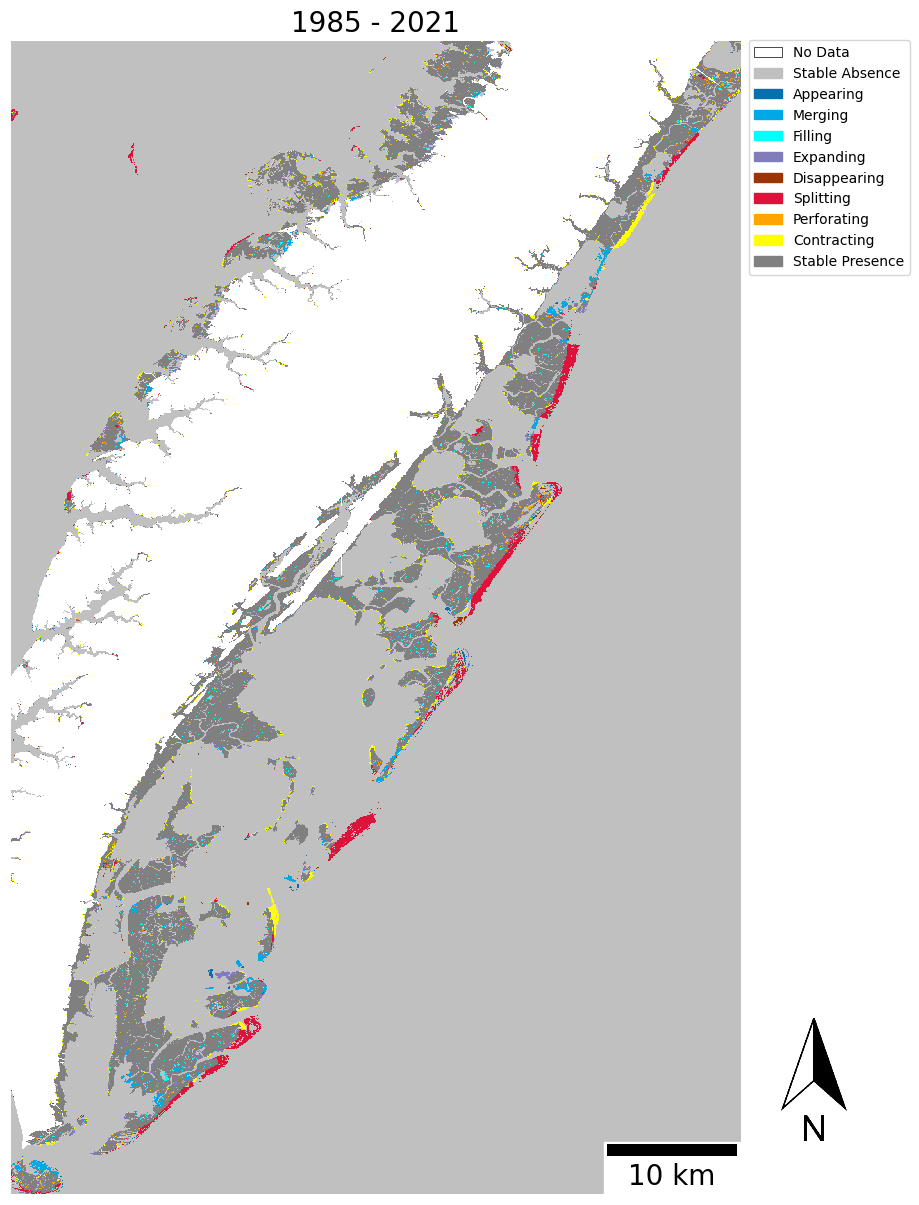

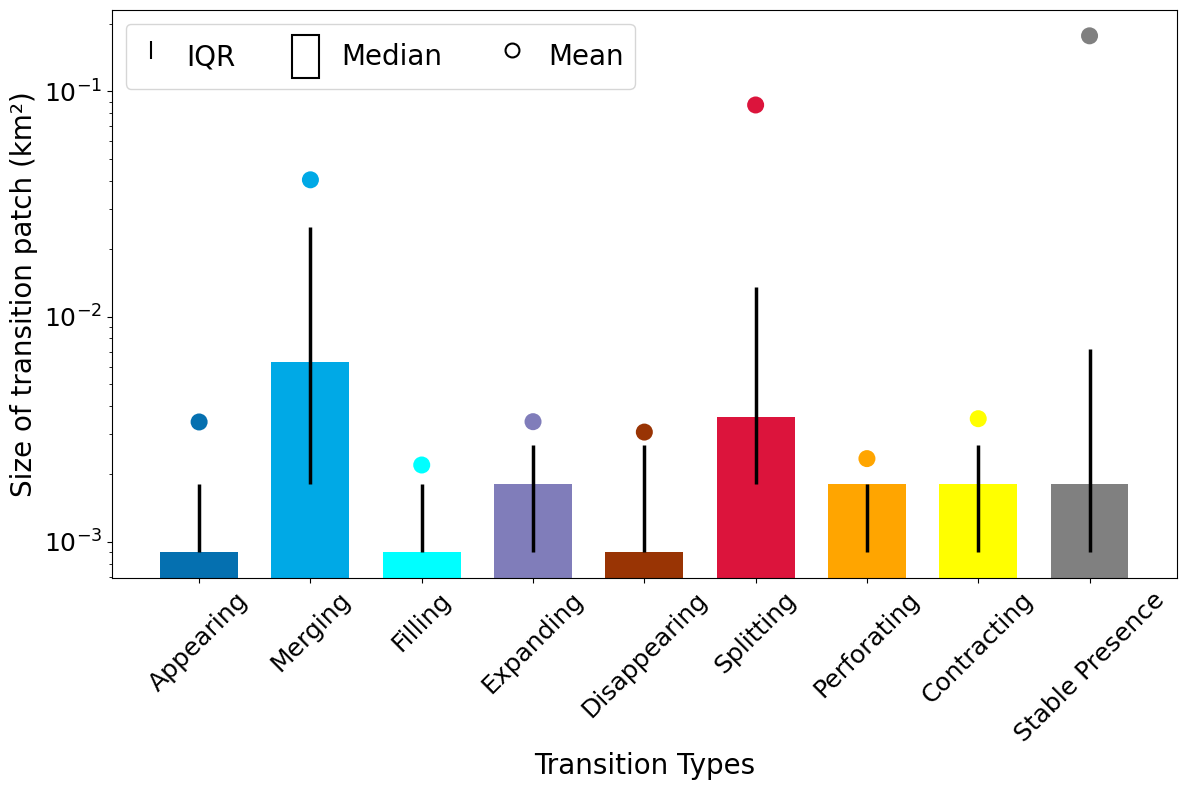

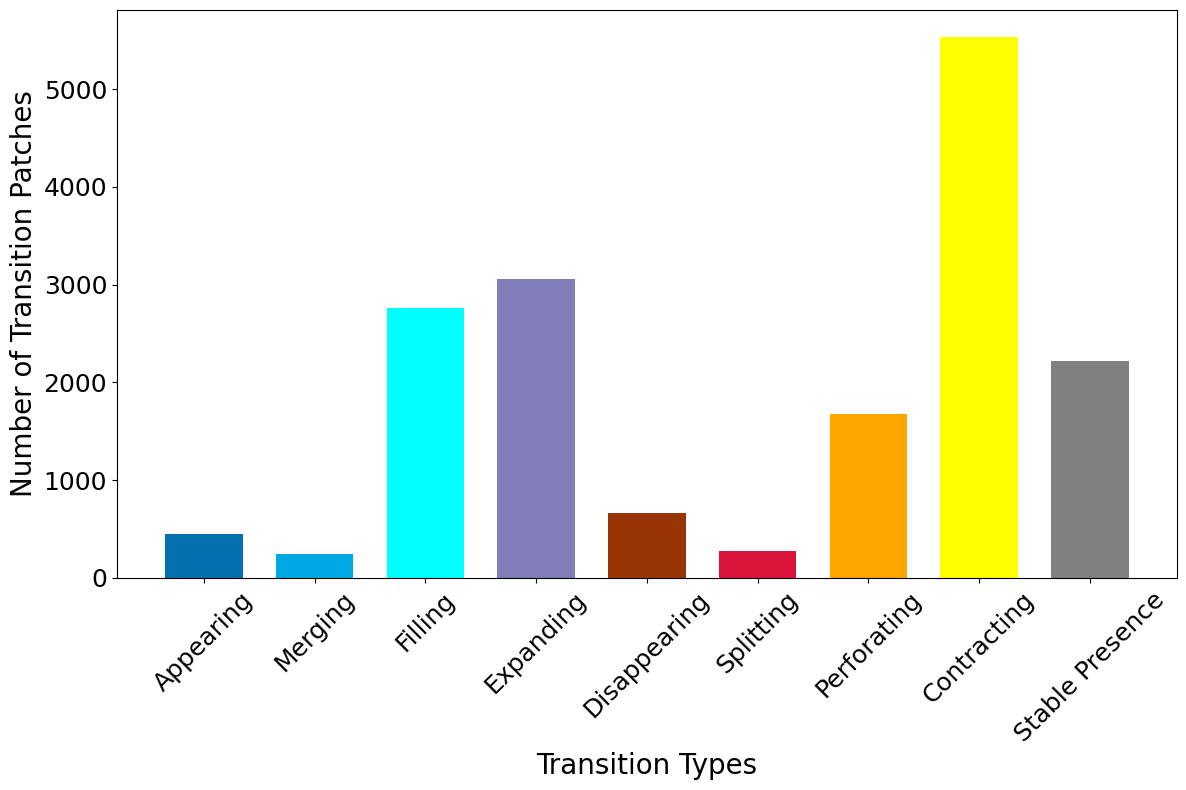

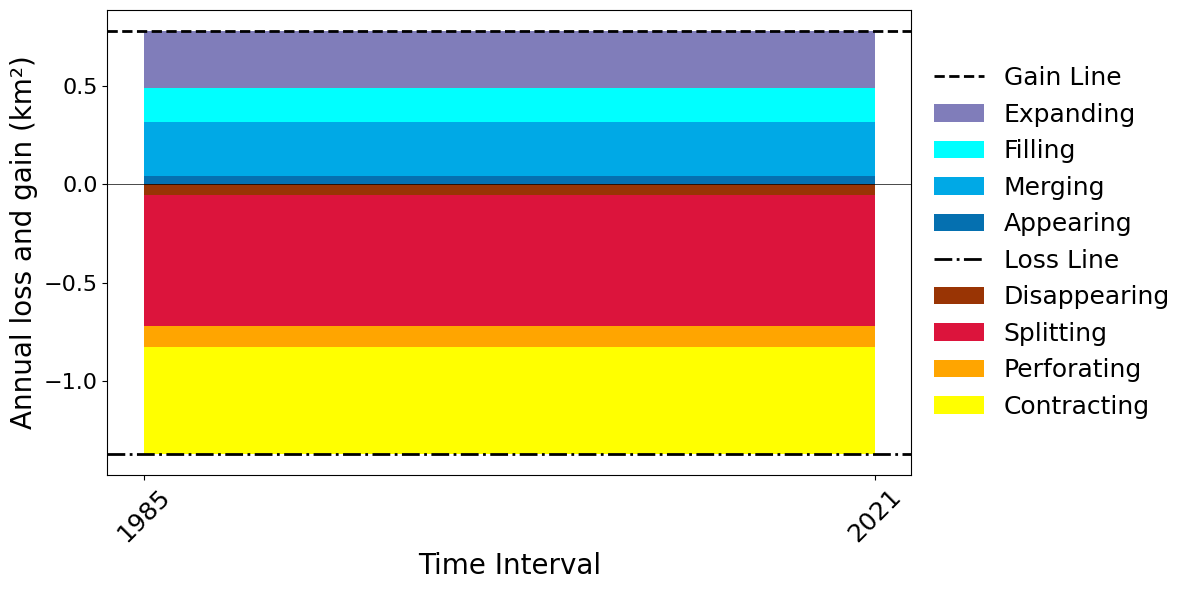

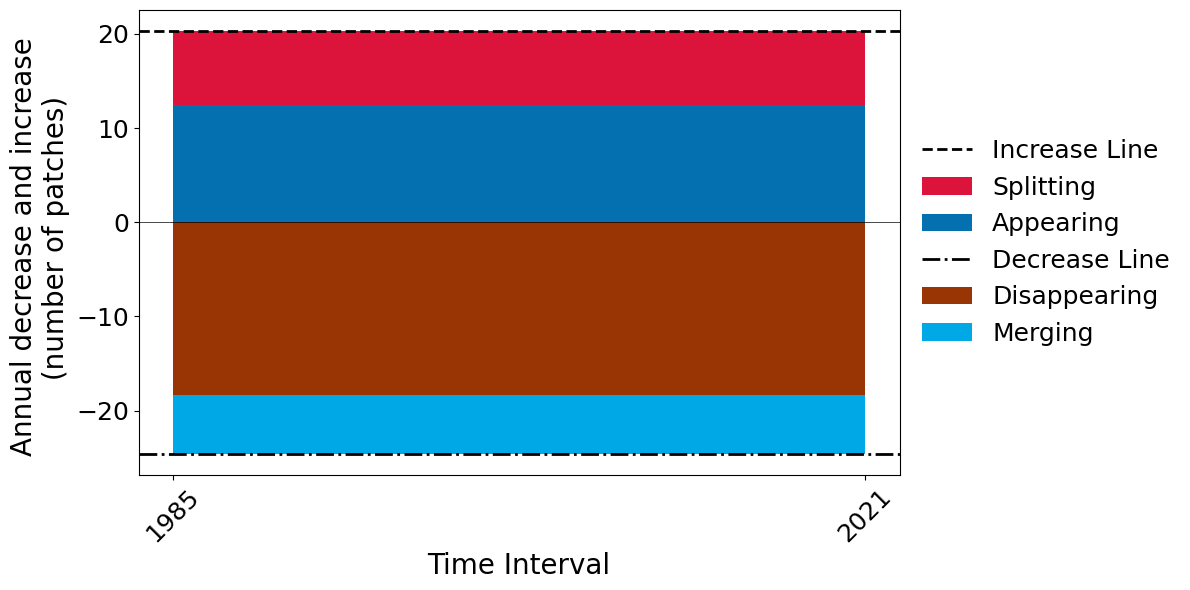

In [8]:
results = dynamicpatch.run_dynamicpatch(
    workpath=str(data_dir),
    year=[1985, 2021],
    targ_pre=2,
    in_nodata=255,
    connectivity=8,
    study_area="VCR marsh",
    map_show=True,
    chart_show=True,
    unit="km2",
    res=30,
    export_map=None,
)

DynamicPATCH displays five figures:

1. the spatial transition-pattern map;
2. the distribution of transition-patch sizes;
3. the number of transition patches by type;
4. gross area gain and loss; and
5. gross increase and decrease in patch count.

The function also returns the underlying map and tables so you can inspect or reuse them.

In [9]:
list(results.keys())

['pattern', 'patch_size', 'patch_num', 'gainloss', 'increase_decrease']

## 4. Interpret the transition map

`results["pattern"]` is a three-dimensional array: one transition map for each consecutive pair of input years. Two input years produce one transition map.

| Code | Transition pattern |
|---:|---|
| -1 | NoData |
| 0 | Stable absence |
| 1 | Appearing |
| 2 | Merging |
| 3 | Filling |
| 4 | Expanding |
| 5 | Disappearing |
| 6 | Splitting |
| 7 | Perforating |
| 8 | Contracting |
| 9 | Stable presence |

In [10]:
pattern = results["pattern"]
print("Pattern array shape:", pattern.shape)

transition_names = {
    -1: "NoData", 0: "Stable absence", 1: "Appearing",
     2: "Merging", 3: "Filling", 4: "Expanding",
     5: "Disappearing", 6: "Splitting", 7: "Perforating",
     8: "Contracting", 9: "Stable presence",
}

values, counts = np.unique(pattern[0], return_counts=True)
pd.DataFrame({
    "code": values,
    "transition": [transition_names[int(value)] for value in values],
    "pixels": counts,
})

Pattern array shape: (1, 2960, 1874)


,code,transition,pixels
0,-1,NoData,1314308
1,0,Stable absence,3711899
2,1,Appearing,1692
3,2,Merging,11074
4,3,Filling,6734
5,4,Expanding,11625
6,5,Disappearing,2253
7,6,Splitting,26413
8,7,Perforating,4354
9,8,Contracting,21652


## 5. Read the four summary tables

### Patch sizes

`patch_size` contains patch-size information for every transition type and time interval. Use it to compare the typical size and variability of appearing, merging, filling, expanding, disappearing, splitting, perforating, and contracting patches.

In [11]:
results["patch_size"]

,year,Stable Absence,Appearing,Merging,Filling,Expanding,Disappearing,Splitting,Perforating,Contracting,Stable Presence
0,1985-2021,0.0018,0.0009,0.0063,0.0009,0.0018,0.0009,0.0036,0.0018,0.0018,0.0018


### Number of patches

`patch_num` counts the patches assigned to each transition type. A transition can occupy a large area because it has many patches, large patches, or both.

In [12]:
results["patch_num"]

,year,Stable Absence,Appearing,Merging,Filling,Expanding,Disappearing,Splitting,Perforating,Contracting,Stable Presence
0,1985,3059,447,246,2762,3062,660,273,1673,5532,2217


### Gross area gain and loss

`gainloss` reports the annual area associated with each transition type. The four gain types are appearing, merging, filling, and expanding. The four loss types are disappearing, splitting, perforating, and contracting.

In [13]:
results["gainloss"]

,year,Appearing,Merging,Filling,Expanding,Disappearing,Splitting,Perforating,Contracting
0,1985,0.0423,0.27685,0.16835,0.290625,-0.056325,-0.660325,-0.10885,-0.5413


### Gross increase and decrease in patch count

`increase_decrease` reports how appearing and splitting increase patch count, while disappearing and merging decrease patch count. These gross changes can be much larger than the net change.

In [14]:
results["increase_decrease"]

,year,Disappearing,Appearing,Splitting,Merging
0,1985,-660.0,447.0,284.0,-224.0


## 6. Read the results together

Use the five outputs as complementary evidence:

- **`pattern`** answers *where* each transition occurred.
- **`patch_size`** shows whether transitions occurred in small or large patches.
- **`patch_num`** shows how frequently each transition occurred.
- **`gainloss`** quantifies gross change in area.
- **`increase_decrease`** quantifies gross change in patch count.

A small net change does not mean that the landscape was stable: gross gains and gross losses may be large and may cancel each other.

## 7. Optional: export the transition map

To save a GeoTIFF, rerun the analysis with `export_map` set to an output path prefix. Do **not** include the `.tif` extension.

```python
output_prefix = Path("output/VCR_marsh_transition")
output_prefix.parent.mkdir(exist_ok=True)

# In run_dynamicpatch, replace export_map=None with:
export_map=str(output_prefix)
```

The exported file will be `output/VCR_marsh_transition.tif`.

## 8. Use your own categorical maps

For another dataset, change the input folder and the dataset-specific values below:

```python
data_dir = Path("path/to/your/maps")
years = [2000, 2010, 2020]
presence_value = 1
nodata_value = 255
cell_size_metres = 30
```

Input maps should represent the same location, use the same coordinate system, cell size, and extent, and have filenames that sort into the same order as `years`. Choose `connectivity=8` for queen connectivity or `connectivity=4` for rook connectivity.

The current developer branch recommends restarting the kernel before changing the input dataset or major parameters, then running the notebook again from the import cell.

## Reference

DynamicPATCH developer branch: <https://github.com/zay1996/DynamicPATCH/tree/developer-branch>

Zhang, A., Pontius Jr, R. G., Bilintoh, T. M., Sangermano, F., & Rogan, J. (2025). *DynamicPATCH: Method and software for spatially explicit dynamic patch transition characterization*. Landscape Ecology, 40(7), 132. <https://doi.org/10.1007/s10980-025-02120-1>